# PUDO Complaint Risk — Waymo CPUC Deployment Data (2024 Q3 – 2026 Q2)

Answers **Step 3** of the risk assessment: is the frequency of PUDO complaints rising or falling, controlling for exposure (miles driven)?

Run `pudo-build` first (or `pudo-build --no-download` if data is already extracted).

In [5]:
from pathlib import Path
import os
import polars as pl
import matplotlib.pyplot as plt

DATA = Path(os.environ.get("PUDO_DATA_DIR", "../data")) / "parquet"
summary = pl.read_parquet(DATA / "pudo_summary.parquet")
monthly = pl.read_parquet(DATA / "monthly_activity.parquet")
pudo_counts = pl.read_parquet(DATA / "pudo_counts.parquet")
complaints = pl.read_parquet(DATA / "complaints.parquet")  # ride-level, 2025Q1+ only

with pl.Config(tbl_cols=-1, tbl_width_chars=200):
    print(summary)
monthly

shape: (8, 16)
┌───────────┬──────┬─────────┬─────────┬──────────────┬──────────────┬───────────┬───────────┬──────────────┬──────────┬────────────┬─────────────┬──────────┬─────────────┬─────────────┬─────────────┐
│ period_id ┆ year ┆ quarter ┆ company ┆ pudo_complai ┆ pudo_collisi ┆ ride_rows ┆ schema    ┆ pudo_travel_ ┆ vmt      ┆ trips      ┆ months_with ┆ n_months ┆ pudo_per_10 ┆ pudo_per_10 ┆ pudo_per_mi │
│ ---       ┆ ---  ┆ ---     ┆ ---     ┆ nts          ┆ ons          ┆ ---       ┆ ---       ┆ lane         ┆ ---      ┆ ---        ┆ _vmt        ┆ ---      ┆ 0k_vmt      ┆ 0k_trips    ┆ llion_rides │
│ str       ┆ i64  ┆ i64     ┆ str     ┆ ---          ┆ ---          ┆ i64       ┆ str       ┆ ---          ┆ f64      ┆ f64        ┆ ---         ┆ u32      ┆ ---         ┆ ---         ┆ ---         │
│           ┆      ┆         ┆         ┆ i64          ┆ i64          ┆           ┆           ┆ i64          ┆          ┆            ┆ u32         ┆          ┆ f64         ┆ f64     

TCPID,TotalTrips,TotalVMTPeriod1,TotalVMTPeriod2,TotalVMTPeriod3,TotalVMTZEV,TotalPassengersCarried,TotalPMT,period_id,analysis_period,company,year,month,quarter,vmt_total
str,f64,f64,f64,f64,f64,f64,f64,str,str,str,i32,i8,i8,f64
"""PSG0038152""",188847.0,424530.89,169059.05,523809.59,1.1174e6,291644.0,799159.95,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,6,2,1.1174e6
"""PSG0038152""",250752.0,546915.07,206038.6,686511.35,1.4395e6,406590.0,1.0949e6,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,7,3,1.4395e6
"""PSG0038152""",312245.0,658598.23,272304.22,897938.83,1.8288e6,499170.0,1.3978e6,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,8,3,1.8288e6
"""PSG0038152""",354124.0,703066.31,313213.03,1.0495e6,2.0657e6,536341.0,1.5531e6,"""2024P4_SepNov""","""2024Q4""","""Waymo""",2024,9,3,2.0657e6
"""PSG0038152""",453478.0,837887.47,372677.49,1.3549e6,2565470.1,670919.0,1944253.5,"""2024P4_SepNov""","""2024Q4""","""Waymo""",2024,10,4,2.5655e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PSG0038152""",1.220222e6,2.2707e6,1218069.7,4.7030e6,8.1917e6,1.530644e6,5.7329e6,"""2026Q1""","""2026Q1""","""Waymo""",2026,2,1,8.1917e6
"""PSG0038152""",1.363067e6,2.4345e6,1.3532e6,5317404.1,9.1051e6,1.717304e6,6.4797e6,"""2026Q1""","""2026Q1""","""Waymo""",2026,3,1,9.1051e6
"""PSG0038152""",1.416158e6,2.4588e6,1.3737e6,5582101.1,9.4145e6,2.207679e6,8.3670e6,"""2026Q2""","""2026Q2""","""Waymo""",2026,4,2,9.4145e6


In [2]:
summary

period_id,year,quarter,company,pudo_complaints,pudo_collisions,ride_rows,schema,pudo_travel_lane,vmt,trips,months_with_vmt,n_months,pudo_per_100k_vmt,pudo_per_100k_trips,pudo_per_million_rides
str,i64,i64,str,i64,i64,i64,str,i64,f64,f64,u32,u32,f64,f64,f64
"""2024Q3""",2024,3,"""Waymo""",41,11,null,"""aggregate""",null,4.3857e6,751844.0,3,3,0.934855,5.453259,null
"""2024Q4""",2024,4,"""Waymo""",51,22,null,"""aggregate""",null,1.1025e7,1.852614e6,4,4,0.46257,2.752867,null
"""2025Q1""",2025,1,"""Waymo""",27,33,2631228,"""microdata""",null,1.1234e7,1.818206e6,3,3,0.24035,1.48498,10.261368
"""2025Q2""",2025,2,"""Waymo""",42,54,3151218,"""microdata""",null,1.3688e7,2.234912e6,3,3,0.306844,1.879269,13.32818
"""2025Q3""",2025,3,"""Waymo""",42,46,3747947,"""microdata""",null,1.7015e7,2.676001e6,3,3,0.246836,1.569506,11.206135
"""2025Q4""",2025,4,"""Waymo""",66,50,4496264,"""microdata""",null,2.4736e7,3.748532e6,3,3,0.266815,1.760689,14.678853
"""2026Q1""",2026,1,"""Waymo""",69,69,4922696,"""microdata""",null,2.6390e7,3.905934e6,3,3,0.261467,1.766543,14.01671
"""2026Q2""",2026,2,"""Waymo""",79,63,4888011,"""microdata""",null,2.8143e7,4.220075e6,3,3,0.280706,1.872005,16.161993


In [3]:
complaints

TCPID,CollisionPUDOPassenger,CollisionPUDOPedestrian,CollisionPUDOBicycleScooter,CollisionPUDOMotorcycles,CollisionPUDOOtherVehicle,CollisionPUDORail,CollisionPUDOProperty,ComplaintSafety,ComplaintPUDO,ComplaintAccessibility,ComplaintWAV,ComplaintCustomerService,ComplaintOther,period_id,raw_period,year,quarter,month,company,source_file,CollisionPUDOAny
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,i32,i8,i8,str,str,bool
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2026Q2""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2026Q2""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2026Q2""","""2026Q2""",2026,2,null,"""Waymo""","""PSG0038152_2026_08_AV_Incident…",false


## 1. Raw counts vs. exposure

Raw complaint counts are expected to rise simply because Waymo's service grew enormously over this window — VMT is the control.

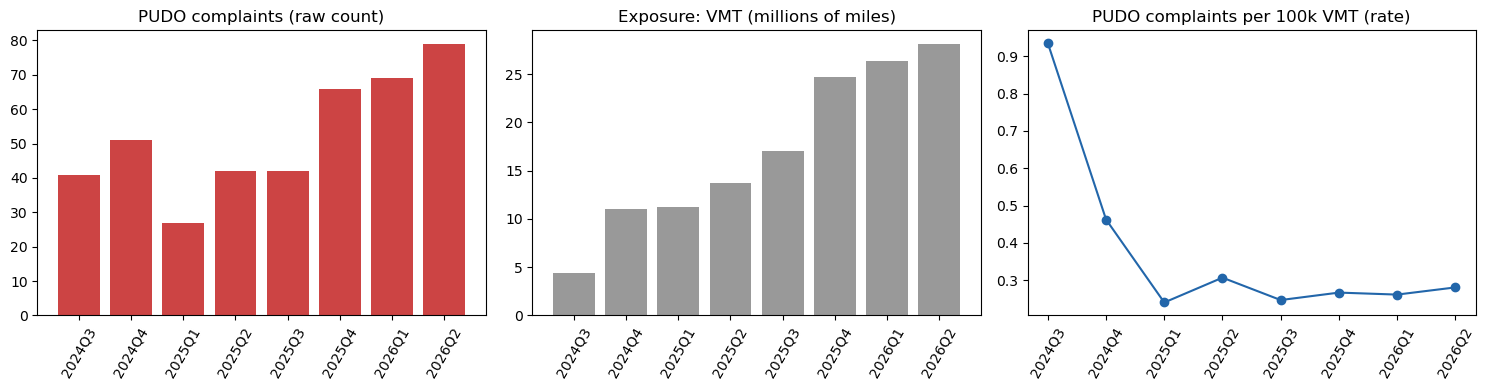

In [4]:
s = summary.to_pandas()
labels = s["period_id"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(labels, s["pudo_complaints"], color="#c44")
axes[0].set_title("PUDO complaints (raw count)")
axes[1].bar(labels, s["vmt"] / 1e6, color="#999")
axes[1].set_title("Exposure: VMT (millions of miles)")
axes[2].plot(labels, s["pudo_per_100k_vmt"], marker="o", color="#26a")
axes[2].set_title("PUDO complaints per 100k VMT (rate)")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## 2. Trend test — Poisson / Negative-Binomial regression with exposure offset

Model: `pudo_complaints ~ t`, `offset = log(VMT)`, where `t` is the period index
0…7 over the eight quarters. The exponentiated slope is the multiplicative change
in the complaint *rate* per quarter.

The window is eight quarters: **2024Q3** (Jun–Aug 2024) and **2024Q4**
(Sep–Dec 2024, the recombined Sep–Nov report + Dec one-month stub) are 3- and
4-month windows; the unequal length is absorbed by the `log(VMT)` offset.

Complaint counts are small and lumpy, so we check overdispersion (Pearson χ²/df)
and fall back to quasi-Poisson / Negative-Binomial (with `alpha` estimated by MLE,
not the statsmodels default of 1) when it is present.

In [5]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

d = (
    s.dropna(subset=["pudo_complaints", "vmt"])
    .sort_values("period_id")
    .reset_index(drop=True)
)
if len(d) < 4:
    raise ValueError(
        f"Only {len(d)} period(s) have exposure (VMT); need >=4 for a trend fit. "
        "Re-run `pudo-build --no-download` and check its warnings — Month_Level "
        "VMT is probably not loading."
    )

d["t"] = np.arange(len(d))
d["log_vmt"] = np.log(d["vmt"].astype(float))
d["pudo_complaints"] = d["pudo_complaints"].astype(float)
X = sm.add_constant(d["t"])

pois = sm.GLM(d["pudo_complaints"], X, family=sm.families.Poisson(),
              offset=d["log_vmt"]).fit()
dispersion = pois.pearson_chi2 / pois.df_resid
overdispersed = dispersion > 1.5
print(f"Poisson Pearson chi2/df = {dispersion:.2f} -> "
      f"{'OVERDISPERSED (report NB)' if overdispersed else 'dispersion OK (report Poisson)'}\n")

# quasi-Poisson: same slope, SEs scaled by sqrt(dispersion)
quasi = sm.GLM(d["pudo_complaints"], X, family=sm.families.Poisson(),
               offset=d["log_vmt"]).fit(scale="X2")
# negative binomial, alpha estimated by MLE
nb = smf.negativebinomial("pudo_complaints ~ t", data=d,
                          offset=d["log_vmt"].values).fit(disp=0)

def summarize(name, res):
    beta = res.params["t"]
    lo, hi = res.conf_int().loc["t"]
    print(f"{name:15s} {np.exp(beta) - 1:+7.1%} / quarter   "
          f"95% CI [{np.exp(lo) - 1:+.1%}, {np.exp(hi) - 1:+.1%}]   "
          f"p = {res.pvalues['t']:.3f}")

summarize("Poisson", pois)
summarize("Quasi-Poisson", quasi)
summarize("Neg. binomial", nb)

primary_name, primary = ("Neg. binomial", nb) if overdispersed else ("Poisson", pois)
change = np.exp(primary.params["t"]) - 1
lo, hi = np.exp(primary.conf_int().loc["t"]) - 1
direction = "RISING" if change > 0 else "FALLING"
sig = "significant at 5%" if primary.pvalues["t"] < 0.05 else "NOT significant at 5%"
print(f"\n>>> Exposure-adjusted PUDO complaint rate is {direction} "
      f"[{primary_name}]: {change:+.1%} per quarter "
      f"(95% CI [{lo:+.1%}, {hi:+.1%}], p = {primary.pvalues['t']:.3f}, {sig}).")

# robustness: drop the 2024Q3 ramp-up quarter (tiny fleet, high leverage)
d2 = d.iloc[1:].reset_index(drop=True)
d2["t"] = np.arange(len(d2))
pois2 = sm.GLM(d2["pudo_complaints"], sm.add_constant(d2["t"]),
               family=sm.families.Poisson(), offset=d2["log_vmt"]).fit()
print(f"\n[robustness] excluding 2024Q3: "
      f"{np.exp(pois2.params['t']) - 1:+.1%} / quarter (Poisson, "
      f"p = {pois2.pvalues['t']:.3f}, Pearson chi2/df = "
      f"{pois2.pearson_chi2 / pois2.df_resid:.2f})")

print(pois.summary())

Poisson Pearson chi2/df = 5.29 -> OVERDISPERSED (report NB)

Poisson          -10.4% / quarter   95% CI [-14.3%, -6.3%]   p = 0.000
Quasi-Poisson    -10.4% / quarter   95% CI [-19.2%, -0.7%]   p = 0.037
Neg. binomial    -12.7% / quarter   95% CI [-19.6%, -5.1%]   p = 0.001

>>> Exposure-adjusted PUDO complaint rate is FALLING [Neg. binomial]: -12.7% per quarter (95% CI [-19.6%, -5.1%], p = 0.001, significant at 5%).

[robustness] excluding 2024Q3: -5.0% / quarter (Poisson, p = 0.052, Pearson chi2/df = 1.90)
                 Generalized Linear Model Regression Results                  
Dep. Variable:        pudo_complaints   No. Observations:                    8
Model:                            GLM   Df Residuals:                        6
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -37.511
Date:        

The Poisson fit is overdispersed (Pearson χ²/df ≈ 5), so the **Negative-Binomial**
row is the one to report. Quasi-Poisson gives the same slope with inflated CIs and
is shown as a cross-check. The `[robustness]` line refits without the 2024Q3
ramp-up quarter, where the fleet was an order of magnitude smaller.

## 3. Supporting view: PUDO collisions

`pudo_collisions` are collisions flagged as occurring during a PUDO (the OR of the
`CollisionPUDO*` columns in the microdata; the 2024 aggregate reports give the
equivalent `CollisionsPUDOAll` total). Kept separate from customer complaints, it
is the severity signal for the risk chart.

> **`PUDOTravelLane` is not plotted.** It is redacted (`"Redacted"`) in every row
> of every file in every period — 2024 aggregate, 2025+ microdata, and
> `Incidents_Location` alike — so there is no travel-lane series to show. The
> pipeline reports `pudo_travel_lane` as null, never zero.

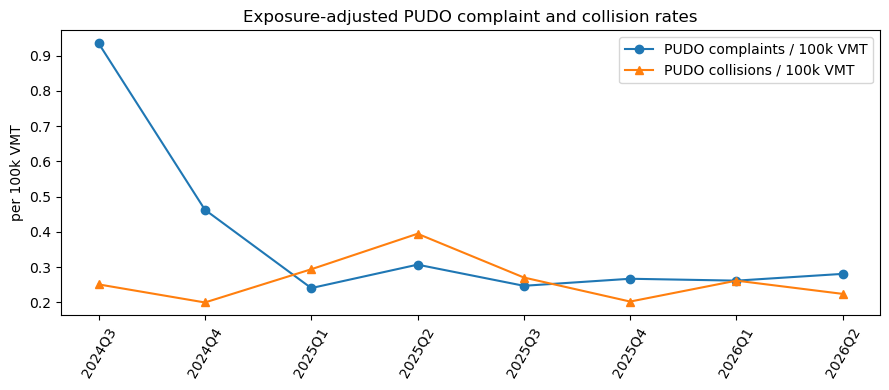

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(labels, s["pudo_per_100k_vmt"], marker="o", label="PUDO complaints / 100k VMT")
ax.plot(labels, s["pudo_collisions"] / s["vmt"] * 1e5, marker="^",
        label="PUDO collisions / 100k VMT")
ax.tick_params(axis="x", rotation=60)
ax.set_ylabel("per 100k VMT")
ax.set_title("Exposure-adjusted PUDO complaint and collision rates")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Risk-chart placement

- **Likelihood**: high. PUDO complaints are the most frequent PUDO-related
  incident class in this dataset, and the raw count rises every quarter as the
  fleet scales.
- **Severity**: predominantly low — customer inconvenience, curb/lane
  obstruction. The PUDO-collision series shows how rarely a PUDO escalates to
  physical contact, and none of the redacted-but-counted collisions are coded
  severe/fatal at the PUDO level.
- **Placement**: high-likelihood / low-consequence → the *medium /
  monitor-and-mitigate* band of a 5×5 matrix.
- **Direction arrow**: the exposure-adjusted (per-VMT) rate is **falling**
  (≈ −13 %/quarter, NB, 95% CI roughly −20 % to −5 %), though almost all of the
  decline is the 2024 ramp-up; from 2025Q1 on the rate is roughly flat at
  ~0.25–0.28 complaints per 100k VMT. So the arrow points slightly **down / flat**:
  the risk is not migrating upward, which supports a *monitor-and-mitigate*
  posture (designated PUDO zones, curb-space management) rather than urgent
  intervention.

*Caveats that belong in the write-up:* complaints are self-reported by Waymo to
its regulator (measures *reported* problems, and reporting propensity may drift);
Waymo entered new cities during the window (rate change can reflect market mix);
the 2024 reporting periods are not calendar quarters; redaction blocks any
within-quarter timing or location analysis; and `PUDOTravelLane` is fully
redacted so the "stopped in a travel lane" severity signal is unavailable.

In [6]:
# CSV snapshots for sharing / the write-up. Defaults to the repo root; override
# with PUDO_EXPORT_DIR.
EXPORT = Path(os.environ.get("PUDO_EXPORT_DIR", Path("..") / "..")).resolve()
EXPORT.mkdir(parents=True, exist_ok=True)

summary.write_csv(EXPORT / "pudo_summary.csv")
monthly.write_csv(EXPORT / "monthly_activity.csv")
# complaints is ride-level and ~24M rows — export a sample, not the whole frame
complaints.sample(n=10_000, seed=42).write_csv(EXPORT / "complaints.csv")
print("wrote pudo_summary.csv, monthly_activity.csv, complaints.csv to", EXPORT)

wrote pudo_summary.csv, monthly_activity.csv, complaints.csv to /home/jon/Documents/grad_school/ai-risk/PUDO
